# Cursos de Machine Learning en el Sector Bancario
## Modulo 10. `Aprobacion de Credito Hipotecario`
                        Elaborado por: Naren Castellon

## `Dataset sintético para predicción de aprobación de crédito hipotecario`

- application_id: ID único de solicitud
# - applicant_id: ID del solicitante (para repetidos)
# - ds: Fecha diaria de solicitud (timestamp)
# - applicant_age: Edad (25-65, típico para hipotecas)
# - annual_income: Ingreso anual (USD)
# - employment_status: Estado laboral ('employed', 'self-employed', 'retired')
# - credit_score: Score crediticio (500-850)
# - debt_to_income_ratio: Ratio deuda/ingreso (0-0.5)
# - loan_amount_requested: Monto solicitado (USD, 50k-500k)
# - property_value: Valor de la propiedad (USD)
# - down_payment: Pago inicial (USD)
# - loan_term_years: Término del préstamo (años, 15-30)
# - interest_rate: Tasa de interés (%, exógena)
# - marital_status: Estado civil ('single', 'married', 'divorced')
# - num_dependents: Número de dependientes (0-4)
# - residence_type: Tipo actual ('rent', 'own_other', 'family')
# - years_at_current_job: Años en empleo actual (0-30)
# - has_previous_mortgage: Tiene hipoteca previa (0/1)
# - previous_default: Default previo (0/1)
# - bank_account_balance: Saldo bancario (USD)
# - is_approved: Target (0/1, ~50-70% aprobación con lógica: buen score, bajo DTI, alto down payment, etc.)
# Frecuencia diaria: Solicitudes diarias con variabilidad.

In [27]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de series temporales
import numpy as np   # Para generación de datos sintéticos numéricos, operaciones matemáticas y arrays
from datetime import datetime, timedelta  # Para generar fechas diarias secuenciales
import random  # Para selección aleatoria de categorías y variabilidad
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y matrices de confusión
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train/test
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Para codificar categóricas y escalar numéricas (importante para ML)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc  # Métricas para evaluar modelo en clases desbalanceadas
from sklearn.ensemble import BaggingClassifier  # Modelo principal: Bagging para ensemble de clasificadores base (reduce varianza)
from sklearn.tree import DecisionTreeClassifier  # Clasificador base para bagging (árboles simples para diversidad)
import shap  # Para explicabilidad: SHAP values para entender contribuciones de features al modelo
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

In [5]:
def generate_mortgage_approval_data(num_applicants=500, num_days=200):
    """
    Genera dataset sintético de solicitudes de crédito hipotecario con frecuencia diaria.
    - num_applicants: Número de solicitantes únicos.
    - num_days: Días totales (total registros ~ num_applicants * num_days).
    Retorna DataFrame con variables realistas para predicción de aprobación.
    """
    np.random.seed(42)  # Reproducibilidad
    random.seed(42)
    
    data = []
    
    start_date = datetime(2023, 1, 1)  # Inicio para datos recientes
    
    for applicant in range(1, num_applicants + 1):
        applicant_id = f'Applicant_{applicant}'  # ID único
        dates = pd.date_range(start=start_date, periods=num_days, freq='D')  # Fechas diarias
        
        # Generar 0-2 solicitudes por día (para ~100k total)
        daily_apps = np.random.randint(0, 3, num_days)
        
        for i in range(num_days):
            for _ in range(daily_apps[i]):
                # ID solicitud único
                app_id = len(data) + 1
                
                # Edad: 25-65 para hipotecas
                age = random.randint(25, 65)
                
                # Ingreso anual: Lognormal
                income = np.random.lognormal(11, 0.5)
                
                # Estado laboral
                employment = random.choice(['employed', 'self-employed', 'retired'])
                
                # Score crediticio: Correlacionado con edad/ingreso
                credit_score = 500 + (age / 65 * 200) + (income / 150000 * 150) + np.random.normal(0, 50)
                credit_score = np.clip(credit_score, 500, 850).astype(int)
                
                # DTI ratio: Bajo para altos ingresos
                dti = np.random.uniform(0.1, 0.3) if income > 80000 else np.random.uniform(0.2, 0.5)
                
                # Monto solicitado: 50k-500k
                loan_amount = random.uniform(50000, 500000)
                
                # Valor propiedad: Mayor que loan_amount
                property_value = loan_amount * random.uniform(1.2, 2.0)
                
                # Pago inicial: 10-30% de property_value
                down_payment = property_value * random.uniform(0.1, 0.3)
                
                # Término: 15-30 años
                loan_term = random.choice([15, 20, 25, 30])
                
                # Tasa interés: 3-6%
                interest_rate = random.uniform(3, 6)
                
                # Estado civil
                marital = random.choice(['single', 'married', 'divorced'])
                
                # Dependientes
                dependents = random.randint(0, 4)
                
                # Residencia actual
                residence = random.choice(['rent', 'own_other', 'family'])
                
                # Años en empleo
                years_job = random.randint(0, 30)
                
                # Hipoteca previa
                has_prev_mortgage = random.choice([0, 1])
                
                # Default previo
                prev_default = random.choice([0, 1]) if has_prev_mortgage else 0
                
                # Saldo bancario
                balance = np.random.normal(10000, 5000) + income * 0.2
                balance = max(balance, 0)
                
                # Aprobación: Lógica (alto score, bajo DTI, alto down payment, no default, etc.)
                approve_prob = 0.5 + 0.25 * (credit_score > 700) - 0.2 * (dti > 0.3) - 0.3 * prev_default + 0.15 * (down_payment / property_value > 0.2) + 0.1 * (years_job > 5)
                is_approved = random.choices([0, 1], weights=[1 - min(approve_prob, 0.99), min(approve_prob, 0.99)])[0]
                
                data.append({
                    'application_id': app_id,
                    'applicant_id': applicant_id,
                    'ds': dates[i],
                    'applicant_age': age,
                    'annual_income': round(income, 2),
                    'employment_status': employment,
                    'credit_score': credit_score,
                    'debt_to_income_ratio': round(dti, 2),
                    'loan_amount_requested': round(loan_amount, 2),
                    'property_value': round(property_value, 2),
                    'down_payment': round(down_payment, 2),
                    'loan_term_years': loan_term,
                    'interest_rate': round(interest_rate, 2),
                    'marital_status': marital,
                    'num_dependents': dependents,
                    'residence_type': residence,
                    'years_at_current_job': years_job,
                    'has_previous_mortgage': has_prev_mortgage,
                    'previous_default': prev_default,
                    'bank_account_balance': round(balance, 2),
                    'is_approved': is_approved
                })
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables (frecuencia diaria).")
    return df

# Generar dataset
mortgage_df = generate_mortgage_approval_data(num_applicants=500, num_days=200)  # ~100k registros

# Guardar como CSV (opcional)
mortgage_df.to_csv('mortgage_approval_data.csv', index=False)

Dataset generado: 99735 registros con 21 variables (frecuencia diaria).


In [6]:
mortgage_df = pd.read_csv("mortgage_approval_data.csv")
mortgage_df

,application_id,applicant_id,ds,applicant_age,annual_income,employment_status,credit_score,debt_to_income_ratio,loan_amount_requested,property_value,...,loan_term_years,interest_rate,marital_status,num_dependents,residence_type,years_at_current_job,has_previous_mortgage,previous_default,bank_account_balance,is_approved
0,1,Applicant_1,2023-01-01,65,42986.05,employed,735,0.28,61254.84,86983.31,...,15,5.03,divorced,0,family,13,0,0,22686.58,0
1,2,Applicant_1,2023-01-01,38,35337.42,employed,614,0.50,277409.88,338780.93,...,30,3.66,divorced,2,rent,24,0,0,19354.56,1
2,3,Applicant_1,2023-01-03,46,48007.71,self-employed,685,0.30,119965.77,235825.18,...,15,4.14,married,2,family,8,0,0,26769.12,1
3,4,Applicant_1,2023-01-03,59,102017.22,employed,658,0.21,487902.09,733232.68,...,25,4.73,divorced,0,rent,21,0,0,37805.09,1
4,5,Applicant_1,2023-01-04,30,40891.87,employed,641,0.31,439917.65,661680.57,...,25,3.49,married,1,family,8,0,0,21817.54,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99730,99731,Applicant_500,2023-07-17,65,78783.12,retired,773,0.32,118730.91,175315.64,...,15,3.94,married,3,rent,2,0,0,34105.61,0
99731,99732,Applicant_500,2023-07-18,65,80771.66,retired,696,0.17,333348.67,539991.59,...,20,4.05,married,3,family,11,1,0,25689.56,1
99732,99733,Applicant_500,2023-07-18,46,65223.44,self-employed,683,0.28,290267.00,396332.61,...,15,5.22,single,4,rent,24,1,0,27255.70,1
99733,99734,Applicant_500,2023-07-19,58,34813.89,self-employed,724,0.23,422544.98,839281.43,...,20,3.72,married,1,rent,3,1,1,11009.47,1


In [7]:
# Paso 2: Análisis Exploratorio de Datos (EDA)
# Convertir ds a datetime
mortgage_df['ds'] = pd.to_datetime(mortgage_df['ds'])

In [8]:
# Resumen estadístico
print("\nEstadísticas descriptivas:")
print(mortgage_df.describe())


Estadísticas descriptivas:
       application_id                             ds  applicant_age  \
count    99735.000000                          99735   99735.000000   
mean     49868.000000  2023-04-10 10:14:38.207249408      45.016815   
min          1.000000            2023-01-01 00:00:00      25.000000   
25%      24934.500000            2023-02-20 00:00:00      35.000000   
50%      49868.000000            2023-04-10 00:00:00      45.000000   
75%      74801.500000            2023-05-30 00:00:00      55.000000   
max      99735.000000            2023-07-19 00:00:00      65.000000   
std      28791.158886                            NaN      11.861250   

       annual_income  credit_score  debt_to_income_ratio  \
count   99735.000000  99735.000000          99735.000000   
mean    68012.049882    705.062947              0.307249   
min      6428.620000    500.000000              0.100000   
25%     42783.090000    657.000000              0.230000   
50%     60009.910000    704.0000

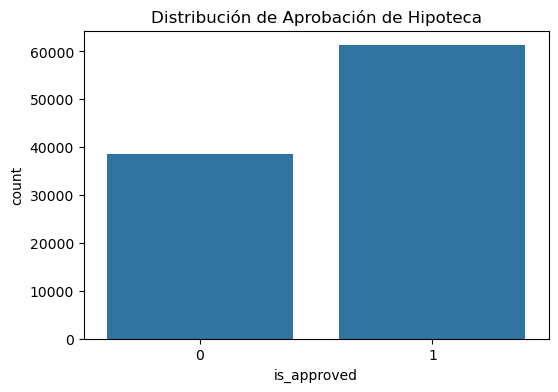

In [9]:
# Distribución de aprobación
plt.figure(figsize=(6, 4))
sns.countplot(x='is_approved', data=mortgage_df)
plt.title('Distribución de Aprobación de Hipoteca')
plt.show()

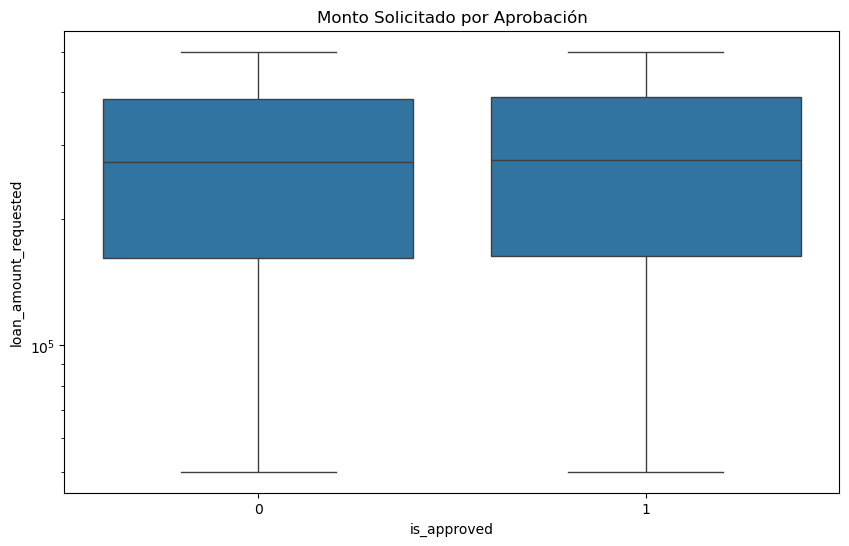

In [10]:
# Monto solicitado por aprobación
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_approved', y='loan_amount_requested', data=mortgage_df)
plt.yscale('log')
plt.title('Monto Solicitado por Aprobación')
plt.show()

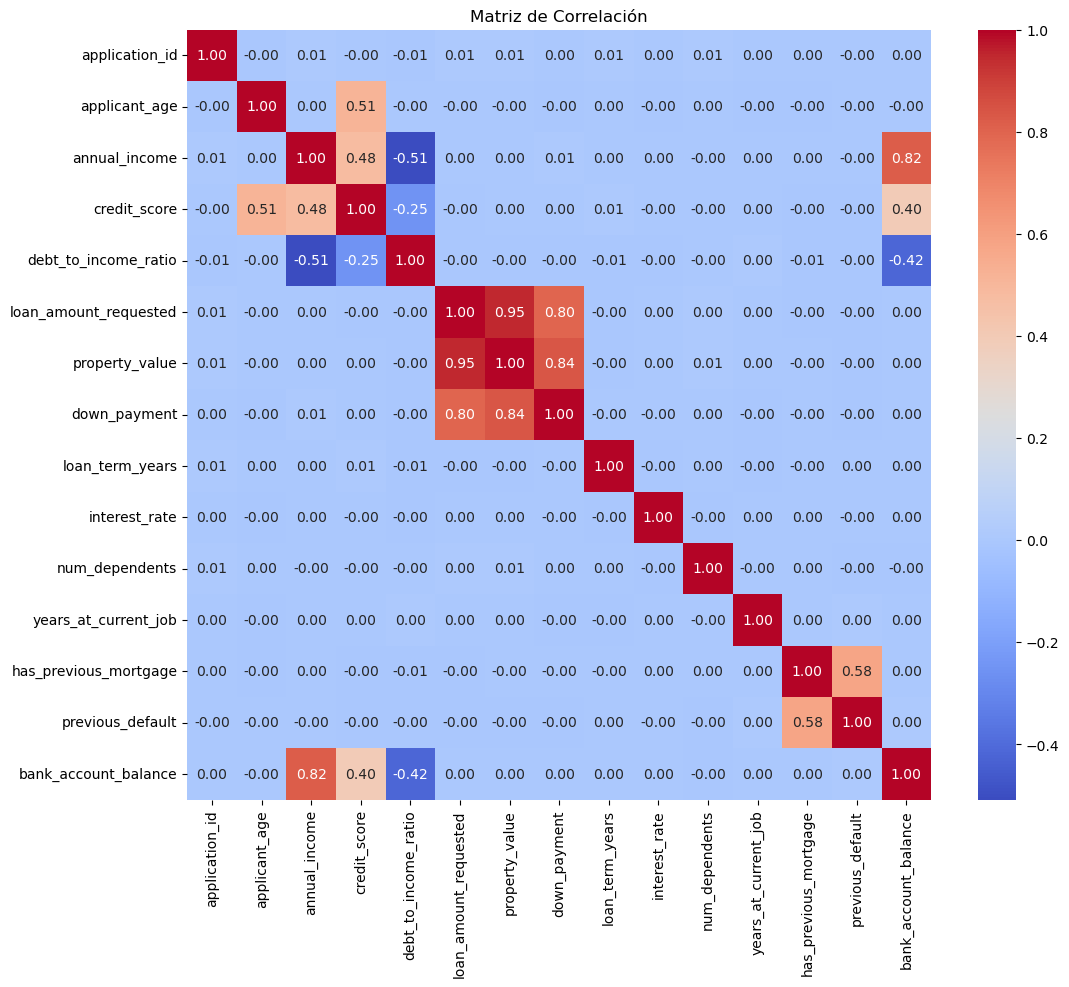

In [11]:
# Correlación numérica
numeric_cols = mortgage_df.select_dtypes(include=[np.number]).columns.drop('is_approved')
corr_matrix = mortgage_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [12]:
# Paso 3: Preprocesamiento para Bagging
# Codificar categóricas
cat_cols = ['employment_status', 'marital_status', 'residence_type']
le_dict = {col: LabelEncoder().fit(mortgage_df[col]) for col in cat_cols}
for col in cat_cols:
    mortgage_df[col] = le_dict[col].transform(mortgage_df[col])

In [13]:
# Escalar numéricas
num_cols = ['applicant_age', 'annual_income', 'credit_score', 'debt_to_income_ratio', 'loan_amount_requested', 'property_value', 'down_payment', 'interest_rate', 'num_dependents', 'years_at_current_job', 'bank_account_balance']
scaler = StandardScaler()
mortgage_df[num_cols] = scaler.fit_transform(mortgage_df[num_cols])

In [14]:
# Dividir train/test (estratificado por aprobación)
X = mortgage_df.drop(columns=['application_id', 'applicant_id', 'ds', 'is_approved'])
y = mortgage_df['is_approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
# Paso 4: Definir y Entrenar Bagging
# Bagging: Ensemble que reduce varianza mediante bootstrap aggregating (muestras con reemplazo) de modelos base
# Base: DecisionTreeClassifier (árboles para no-linealidades)
# Usamos n_estimators=50 para demo (en real, 100-500)
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=0.8,  # 80% de muestras por base
    max_features=0.8,  # 80% de features por base
    bootstrap=True,
    n_jobs=-1,  # Paralelo
    random_state=42
)

bagging_model

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_features=0.8, max_samples=0.8, n_estimators=50, n_jobs=-1,
                  random_state=42)

In [21]:
bagging_model.fit(X_train, y_train)

print("Modelo Bagging entrenado.")

Modelo Bagging entrenado.


In [16]:
# Paso 5: Evaluación del Modelo
y_pred = bagging_model.predict(X_test)
y_prob = bagging_model.predict_proba(X_test)[:, 1]

In [17]:
# Reporte y métricas
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.62      0.51      0.56      7695
           1       0.72      0.81      0.76     12252

    accuracy                           0.69     19947
   macro avg       0.67      0.66      0.66     19947
weighted avg       0.69      0.69      0.69     19947



In [18]:
roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.7511
PR-AUC: 0.8307


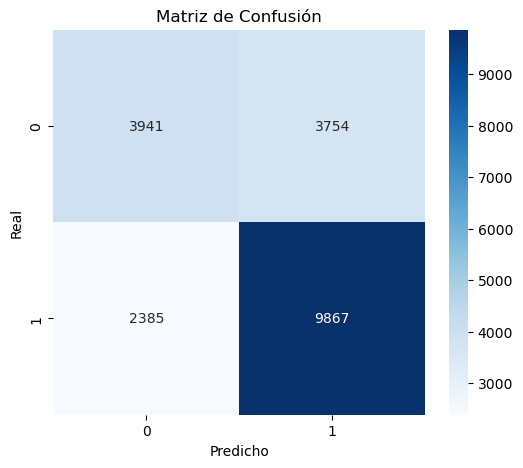

In [23]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()



In [24]:
# Paso 6: Sección para Medir el Riesgo de Aprobación
# Riesgo: Basado en probabilidad (e.g., bajo <30%, medio 30-70%, alto >70%)
# Agregamos categorización de riesgo y visualización de distribución en test set
risk_levels = pd.cut(y_prob, bins=[0, 0.3, 0.7, 1.0], labels=['Bajo Riesgo (Alta Prob Aprob)', 'Medio Riesgo', 'Alto Riesgo (Baja Prob Aprob)'])
risk_df = pd.DataFrame({'Probabilidad': y_prob, 'Riesgo': risk_levels, 'Real Aprobado': y_test})
print("\nDistribución de Riesgo en Test Set:")
print(risk_df['Riesgo'].value_counts(normalize=True))


Distribución de Riesgo en Test Set:
Riesgo
Medio Riesgo                     0.612273
Alto Riesgo (Baja Prob Aprob)    0.322605
Bajo Riesgo (Alta Prob Aprob)    0.065123
Name: proportion, dtype: float64


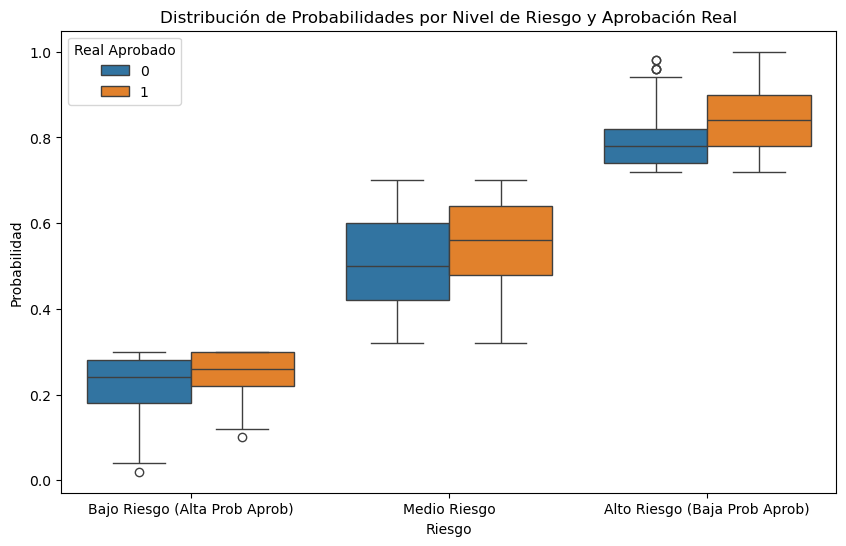

In [25]:
# Visualizar riesgo vs real
plt.figure(figsize=(10, 6))
sns.boxplot(x='Riesgo', y='Probabilidad', hue='Real Aprobado', data=risk_df)
plt.title('Distribución de Probabilidades por Nivel de Riesgo y Aprobación Real')
plt.show()

In [28]:
# Paso 7: Implementar SHAP para Explicabilidad
# SHAP: Analiza contribuciones de features a predicciones (crucial en banca para transparencia)
explainer = shap.Explainer(bagging_model, X_train)  # Explainer para ensemble (usa TreeExplainer internamente si bases son trees)

# SHAP values en muestra de test (para eficiencia)
X_test_sample = X_test.sample(1000)
shap_values = explainer(X_test_sample)

# Resumen global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
plt.title('Importancia Global de Features (SHAP)')
plt.show()

# Resumen detallado
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample)
plt.title('Impacto Detallado de Features (SHAP)')
plt.show()

# Ejemplo individual (primera instancia)
shap.plots.waterfall(shap_values[0])
plt.title('SHAP Waterfall para Solicitud Ejemplo')
plt.show()

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_features=0.8, max_samples=0.8, n_estimators=50, n_jobs=-1,
                  random_state=42)

Exception ignored in: <function ResourceTracker.__del__ at 0x104bdac00>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1022bac00>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function 